### author by yangshichen
### 注意：脚本仅供参考，使用前请仔细阅读

In [1]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn as sns
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from scipy.sparse import issparse
import decoupler as dc
from sklearn.preprocessing import QuantileTransformer
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.preprocessing import QuantileTransformer, StandardScaler
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
scaler = StandardScaler()

import warnings
warnings.filterwarnings("ignore")

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, frameon=False)
sc._settings.ScanpyConfig.n_jobs=70

scanpy==1.9.8 anndata==0.9.2 umap==0.5.7 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 pynndescent==0.5.13


In [3]:
import os
os.environ["R_HOME"] = "/home/yangshichen//mambaforge/envs/QTL/lib/R"
os.environ["R_LIBS_USER"] = "/home/yangshichen/mambaforge/envs/QTL/lib/R/library"
import pandas as pd
import torch
import tensorqtl
from tensorqtl import  cis
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} (CUDA {torch.version.cuda}), device: {device}")
print(f"pandas: {pd.__version__}")

torch: 2.4.1+cu121 (CUDA 12.1), device: cpu
pandas: 2.0.3


### Use tensorqtl-pQTL

#### protein value.csv转bed

In [4]:
# 基因注释表（必须包含 gene_id, chrom, start, end）
annotation_df = pd.read_csv("/media/AnalysisDisk2/Yangshichen/0_HIV_RNA/QTL/Data/Genotype/gene_annotation.txt", sep='\t')
annotation_df = annotation_df.rename(columns={
    "gene_id": "gene_id",
    "chr": "chr",
    "left": "start",
    "right": "end"})
annotation_df

,gene_id,chr,start,end
0,DDX11L17,chr1,182696,184174
1,PRDM16,chr1,3069168,3438621
2,PEX10,chr1,2403964,2413797
3,RPL21P21,chr1,10054445,10054781
4,LINC01345,chr1,3944547,3949024
...,...,...,...,...
41008,ZNF736P9Y,chrY,8068896,8070723
41009,FAM197Y8,chrY,9354846,9356814
41010,PRKY,chrY,7274313,7371868
41011,SEPTIN14P23,chrY,25378300,25394719


In [5]:
import pandas as pd
import re
def chrom_sort_key(chrom):
    # 提取数字部分（chr1 → 1, chrX → 23, chrY → 24）
    match = re.match(r'chr(\d+)$', chrom)
    if match:
        return int(match.group(1))
    elif chrom == 'chrX':
        return 23
    elif chrom == 'chrY':
        return 24
    elif chrom == 'chrM':
        return 25
    else:
        return 100  # 把奇怪的染色体排到后面

In [6]:
protein_to_gene = {
    "IL8": "CXCL8",
    "VEGFA": "VEGFA",
    "CD8A": "CD8A",
    "MCP-3": "CCL7",
    "CDCP1": "CDCP1",
    "CD244": "CD244",
    "IL7": "IL7",
    "OPG": "TNFRSF11B",
    "LAP TGF-beta-1": "TGFB1",
    "uPA": "PLAU",
    "IL6": "IL6",
    "IL-17C": "IL17C",
    "MCP-1": "CCL2",
    "CXCL11": "CXCL11",
    "AXIN1": "AXIN1",
    "TRAIL": "TNFSF10",
    "CXCL9": "CXCL9",
    "CST5": "CST5",
    "OSM": "OSM",
    "CXCL1": "CXCL1",
    "CCL4": "CCL4",
    "CD6": "CD6",
    "SCF": "KITLG",
    "IL18": "IL18",
    "SLAMF1": "SLAMF1",
    "TGF-alpha": "TGFA",
    "MCP-4": "CCL13",
    "CCL11": "CCL11",
    "TNFSF14": "TNFSF14",
    "FGF-23": "FGF23",
    "IL-10RA": "IL10RA",
    "MMP-1": "MMP1",
    "LIF-R": "LIFR",
    "FGF-21": "FGF21",
    "CCL19": "CCL19",
    "IL-10RB": "IL10RB",
    "IL-18R1": "IL18R1",
    "PD-L1": "CD274",
    "CXCL5": "CXCL5",
    "TRANCE": "TNFSF11",
    "HGF": "HGF",
    "IL-12B": "IL12B",
    "MMP-10": "MMP10",
    "IL10": "IL10",
    "TNF": "TNF",
    "CCL23": "CCL23",
    "CD5": "CD5",
    "CCL3": "CCL3",
    "Flt3L": "FLT3LG",
    "CXCL6": "CXCL6",
    "CXCL10": "CXCL10",
    "4E-BP1": "EIF4EBP1",
    "SIRT2": "SIRT2",
    "CCL28": "CCL28",
    "DNER": "DNER",
    "EN-RAGE": "S100A12",
    "CD40": "CD40",
    "IFN-gamma": "IFNG",
    "FGF-19": "FGF19",
    "MCP-2": "CCL8",
    "CASP-8": "CASP8",
    "CCL25": "CCL25",
    "CX3CL1": "CX3CL1",
    "TNFRSF9": "TNFRSF9",
    "NT-3": "NTF3",
    "TWEAK": "TNFSF12",
    "CCL20": "CCL20",
    "ST1A1": "SULT1A1",
    "STAMBP": "STAMBP",
    "ADA": "ADA",
    "TNFB": "LTA",
    "CSF-1": "CSF1"
}

# 替换函数
def replace_protein_with_gene(df, mode="merge"):
    df = df.copy()
    df['gene_id'] = df['gene_id'].map(protein_to_gene)

    if mode == "merge":
        # 默认行为：保留合并后的字符串，如 CD3D/CD3E/CD3G
        return df

    elif mode == "split_rows":
        # 拆分为多行
        df = df.dropna(subset=['gene_id'])  # 防止 NaN 报错
        df = df.assign(Gene=df['gene_id'].str.split('/')).explode('gene_id').reset_index(drop=True)
        return df

    elif mode == "first_only":
        # 仅保留第一个基因
        df['gene_id'] = df['gene_id'].str.split('/').str[0]
        return df

    else:
        raise ValueError("mode must be 'merge', 'split_rows', or 'first_only'")

In [7]:
import pandas as pd
import pyranges as pr

expr_df = pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink_Filter_int.csv', index_col=0).T
expr_df.index.name = 'gene_id'
expr_df.reset_index(inplace=True)
expr_df = replace_protein_with_gene(expr_df, mode="split_rows")
expr_df = expr_df.assign(gene_id=expr_df['gene_id'].str.split('/')).explode('gene_id').reset_index(drop=True)

#合并注释
merged_df = annotation_df.merge(expr_df, on='gene_id')
merged_df = merged_df[['chr', 'start', 'end', 'gene_id'] + list(expr_df.columns[1:])]

#按照染色体顺序排序（否则会报错）
autosomes = [f"chr{i}" for i in range(1, 23)]
merged_df = merged_df[merged_df["chr"].isin(autosomes)]
merged_df['chr_sort_key'] = merged_df['chr'].apply(chrom_sort_key)
merged_df = merged_df.sort_values(by=['chr_sort_key', 'start', 'end']).drop(columns='chr_sort_key').reset_index(drop=True)

#保存为bed和csv格式
merged_df.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink_72.csv', sep=',', index=False)
merged_df.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink_72.bed',  sep='\t', index=False, header=True)

merged_df

,chr,start,end,gene_id,HP-1,HP-10,HP-101,HP-103,HP-104,HP-105,...,HP-950,HP-951,HP-952,HP-953,HP-954,HP-955,HP-956,HP-957,HP-98,Gene
0,chr1,7915871,7943165,TNFRSF9,1.324431,2.371635,0.142533,-0.436688,-0.728428,-0.375617,...,0.423703,0.106741,-0.245105,0.595727,-0.694126,-0.832798,0.755710,1.557953,-0.592197,[TNFRSF9]
1,chr1,109910242,109930992,CSF1,2.117252,-0.079990,0.571167,-0.550386,-0.378794,0.118655,...,-1.113151,0.394741,1.086066,0.540085,-0.306597,-0.462884,0.866769,0.803843,-0.340904,[CSF1]
2,chr1,153373711,153375621,S100A12,2.484125,0.906225,1.473947,1.609816,0.713079,1.289667,...,-1.193725,-0.617068,0.599265,-0.291124,-0.980100,-1.599096,-0.627844,-0.417237,1.448134,[S100A12]
3,chr1,160608106,160647044,SLAMF1,-0.536664,1.360873,0.420467,-0.906225,-0.924220,-0.871086,...,-0.578148,0.172498,1.059755,1.407139,0.053295,-0.989714,0.664308,0.984896,-0.109718,[SLAMF1]
4,chr1,160830160,160862887,CD244,0.226847,1.953441,0.543513,-0.109718,-1.303383,0.112696,...,-1.152503,0.407570,1.439740,0.469482,-0.407570,-0.272648,1.152503,0.251209,-0.564213,[CD244]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,chr20,23875934,23879748,CST5,0.476101,-0.482741,0.385161,-1.548069,-0.845423,0.439946,...,-0.970577,0.690365,0.502790,0.820305,-0.160495,0.394741,0.645968,0.546946,-0.303497,[CST5]
68,chr20,44584896,44652252,ADA,1.135422,0.414010,1.039222,0.751779,-0.866769,0.512890,...,-0.112696,0.807938,-0.065153,1.124217,-0.910696,-0.832798,0.592197,0.599265,-0.697896,[ADA]
69,chr20,46118271,46129863,CD40,1.994982,1.019119,0.771555,-1.019119,-0.263445,0.459593,...,-1.249905,0.217746,0.407570,0.115675,-0.079990,-1.135422,0.154502,0.564213,-0.724575,[CD40]
70,chr21,33266367,33311420,IL10RB,0.638693,1.075452,0.550386,-0.229884,-1.164079,0.476101,...,-0.439946,-0.350329,0.862469,-0.871086,0.118655,-0.828619,0.449747,0.193564,-0.269578,[IL10RB]


#### Read genotype_df and vatiant_df

In [8]:
genotype_df = pd.read_parquet('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_genotype.parquet')
variant_df = pd.read_parquet('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_variant_df.parquet')
variant_df['chrom'] = 'chr' + variant_df['chrom'].astype(str)

#### 去除HP-929

In [9]:
genotype_df = genotype_df.drop(columns=["HP-929"])
genotype_df

,HP-1,HP-10,HP-101,HP-103,HP-104,HP-105,HP-106,HP-107,HP-108,HP-109,...,HP-95,HP-950,HP-951,HP-952,HP-953,HP-954,HP-955,HP-956,HP-957,HP-98
variant_id,,,,,,,,,,,,,,,,,,,,,
1:10583:G:A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:13504:G:A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:13649:G:C,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
1:13752:T:C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1:13868:A:G,1,0,1,1,2,1,0,1,0,1,...,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22:50807608:T:C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22:50807681:C:A,1,0,1,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
22:50807685:G:C,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [10]:
variant_df

,chrom,pos,ref,alt
variant_id,,,,
1:10583:G:A,chr1,10583,G,A
1:13504:G:A,chr1,13504,G,A
1:13649:G:C,chr1,13649,G,C
1:13752:T:C,chr1,13752,T,C
1:13868:A:G,chr1,13868,A,G
...,...,...,...,...
22:50807608:T:C,chr22,50807608,T,C
22:50807681:C:A,chr22,50807681,C,A
22:50807685:G:C,chr22,50807685,G,C


#### Run tensorqtl

In [15]:
#read_expression_file and covariates
expression_bed = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink_72.bed'
covariates_file = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/01.factor.csv'

#load phenotypes and covariates
#align phenotypes and covariates
phenotype_df, phenotype_pos_df = tensorqtl.read_phenotype_bed(expression_bed)
covariates_df = pd.read_csv(covariates_file, sep=',', index_col=0)
phenotype_df = phenotype_df[covariates_df.index]

#decited the number of peer factor
covariates_df = covariates_df.dropna(axis=1)

#cis-QTL mapping: permutations (对每个基因，寻找在附近（cis-window，一般是±1Mb）的SNP是否与其表达量显著相关。)
cis_df = cis.map_cis(genotype_df, variant_df, phenotype_df, phenotype_pos_df, covariates_df, 
                    maf_threshold=0.1, seed=8888)

#后续统一再在py里面算（环境问题）
#tensorqtl.calculate_qvalues(cis_df)

#保存
cis_df.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL/all_lead_perm.csv')

#cis-QTL mapping: summary statistics for all variant-phenotype pairs（所有变异-表型对的统计汇总）
cis.map_nominal(genotype_df, variant_df, phenotype_df, phenotype_pos_df, 'all', covariates_df, maf_threshold=0.1, 
                output_dir='/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL/')

cis-QTL mapping: empirical p-values for phenotypes
  * 847 samples
  * 72 phenotypes
  * 66 covariates
  * 6990104 variants
  * applying in-sample 0.1 MAF filter
  * cis-window: ±1,000,000
  * using seed 8888
  * checking phenotypes: 72/72
    ** dropping 6 phenotypes without variants in cis-window
  * computing permutations
    processing phenotype 66/66
  Time elapsed: 1.33 min
done.
cis-QTL mapping: nominal associations for all variant-phenotype pairs
  * 847 samples
  * 72 phenotypes
  * 66 covariates
  * 6990104 variants
  * applying in-sample 0.1 MAF filter
  * cis-window: ±1,000,000
  * checking phenotypes: 72/72
    ** dropping 6 phenotypes without variants in cis-window
  * Computing associations
    Mapping chromosome chr1
    processing phenotype 1/66    time elapsed: 0.01 min
    * writing output
    Mapping chromosome chr2
    processing phenotype 8/66    time elapsed: 0.07 min
    * writing output
    Mapping chromosome chr3
    processing phenotype 10/66    time elapsed:

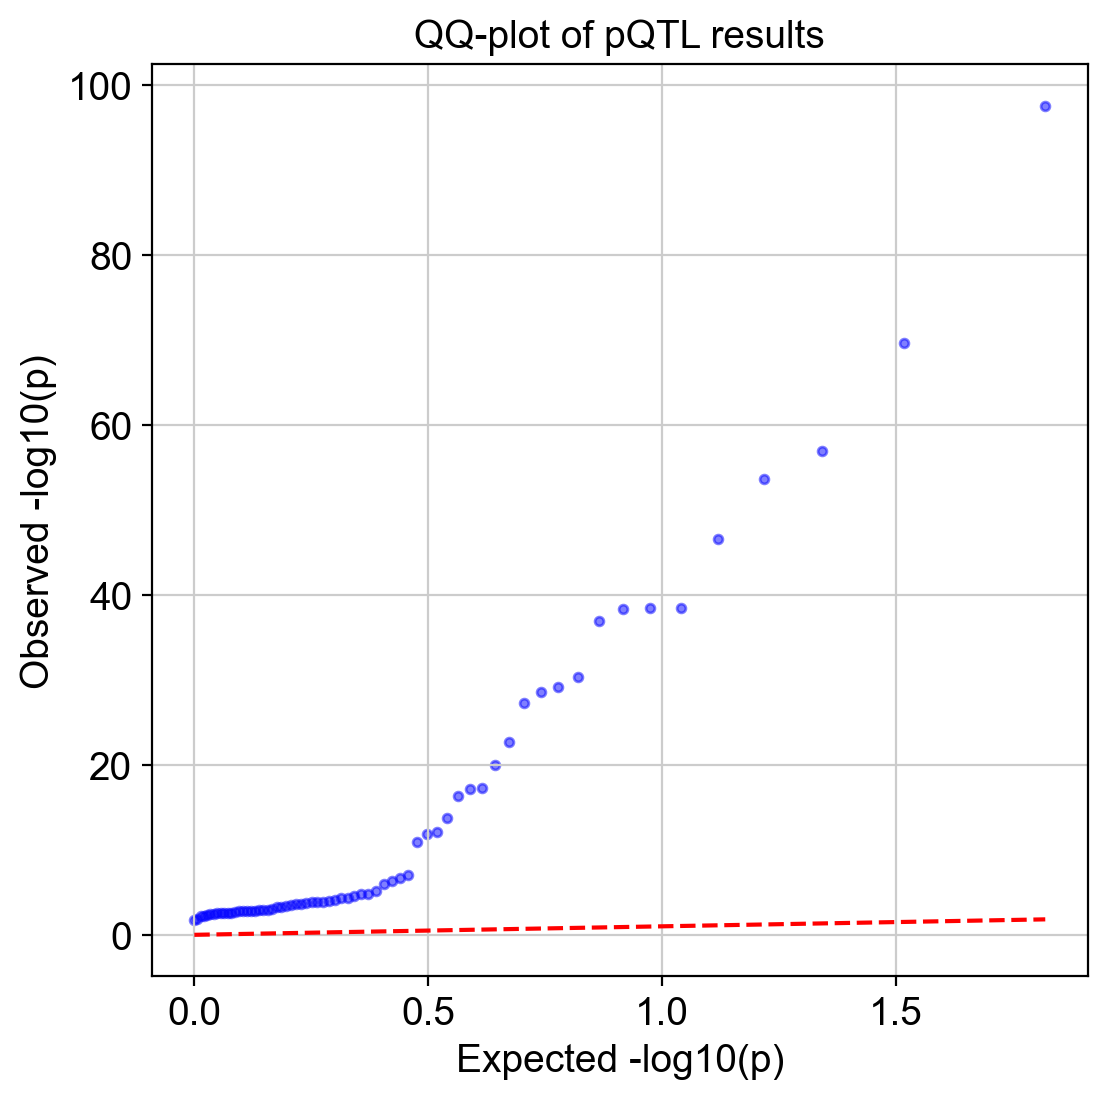

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读入结果
df = pd.read_csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL/all_lead_perm.csv", sep=",")

# 提取 p 值
pvals = df['pval_nominal'].dropna().values
pvals = np.clip(pvals, 1e-300, 1)  # 避免取 log 出现 -inf

# 排序后的观测和期望
observed = -np.log10(np.sort(pvals))
expected = -np.log10(np.linspace(1/len(pvals), 1, len(pvals)))

# QQ-plot
plt.figure(figsize=(6,6))
plt.scatter(expected, observed, s=10, c="blue", alpha=0.5)
plt.plot([0, max(expected)], [0, max(expected)], color="red", linestyle="--")
plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ-plot of pQTL results")
plt.show()

In [17]:
#read_expression_file and covariates
cis_df = pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL/all_lead_perm.csv')
cis_df['celltype'] = 'bulk'
    
#tensorqtl.calculate_qvalues
from statsmodels.stats.multitest import fdrcorrection
pvals = cis_df['pval_perm'].values
rej, qvals = fdrcorrection(pvals, alpha=0.05)
cis_df['qval'] = qvals

#修改名字
cis_df = cis_df.rename(columns={"qval": "celltype_level_qval"})

print(len(cis_df[cis_df['celltype_level_qval'] < 0.05]['phenotype_id'].unique()))

#保存
cis_df.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL_all_lead_perm_qvalue.csv')

29


### Summary

In [21]:
tmp = pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL_all_lead_perm_qvalue.csv')
tmp

,Unnamed: 0,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,ma_count,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval
0,0,TNFRSF9,2931,1.037246,244.12580,665.91100,3.415041e-11,1:7930307:G:A,14435,-12858,508,633,0.373672,7.579449e-13,0.080948,0.011103,0.000100,4.102973e-09,bulk,0.000275
1,1,TGFA,4200,1.045852,215.28009,657.23810,2.567994e-03,2:71162435:A:G,715150,608242,252,275,0.162338,1.027633e-03,-0.055942,0.016976,0.411959,4.029633e-01,bulk,0.572630
2,2,STAMBP,2376,1.027429,120.31133,669.76654,6.564908e-03,2:73851587:G:T,22670,-22072,504,611,0.360685,3.372383e-03,-0.020367,0.006926,0.541346,5.344444e-01,bulk,0.677491
3,3,CD8A,2274,1.036028,122.80860,659.01587,7.946111e-05,2:86718032:A:G,-66579,-90364,200,214,0.126328,1.782915e-05,0.149792,0.034695,0.006899,8.092419e-03,bulk,0.016865
4,4,IL18R1,3338,1.045319,137.80128,644.58215,4.551357e-48,2:102368964:A:G,57434,-29813,616,798,0.471074,1.002602e-57,0.369964,0.021220,0.000100,5.499434e-48,bulk,0.000275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,61,CST5,3839,1.041426,195.89844,657.36830,3.132027e-33,20:23879541:A:G,3606,-207,622,828,0.488784,4.563654e-39,0.369955,0.026748,0.000100,3.376596e-32,bulk,0.000275
62,62,ADA,3087,1.054076,256.13092,670.29090,1.548301e-06,20:44641459:A:G,56562,-10793,278,301,0.177686,2.216866e-07,0.117399,0.022461,0.000100,2.535098e-04,bulk,0.000275
63,63,CD40,3228,1.049854,220.09155,656.49164,5.540686e-32,20:46103450:T:C,-14822,-26413,511,627,0.370130,1.226225e-37,-0.166004,0.012265,0.000100,4.317602e-31,bulk,0.000275
64,64,IL10RB,2735,1.030987,178.58151,665.22705,9.489119e-15,21:33287563:C:T,21195,-23857,329,362,0.213695,5.175605e-17,0.147571,0.017203,0.000100,7.219920e-13,bulk,0.000275


In [24]:
tmp = tmp[tmp["celltype_level_qval"] < 0.05]
tmp

,Unnamed: 0,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,ma_count,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval
0,0,TNFRSF9,2931,1.037246,244.125800,665.91100,3.415041e-11,1:7930307:G:A,14435,-12858,508,633,0.373672,7.579449e-13,0.080948,0.011103,0.000100,4.102973e-09,bulk,0.000275
3,3,CD8A,2274,1.036028,122.808600,659.01587,7.946111e-05,2:86718032:A:G,-66579,-90364,200,214,0.126328,1.782915e-05,0.149792,0.034695,0.006899,8.092419e-03,bulk,0.016865
4,4,IL18R1,3338,1.045319,137.801280,644.58215,4.551357e-48,2:102368964:A:G,57434,-29813,616,798,0.471074,1.002602e-57,0.369964,0.021220,0.000100,5.499434e-48,bulk,0.000275
8,8,CDCP1,2437,1.018199,116.833990,659.80630,7.122759e-05,3:45129013:G:A,46735,-17409,250,276,0.162928,1.586707e-05,0.086109,0.019824,0.007399,7.537155e-03,bulk,0.017441
10,10,CXCL8,2868,1.021759,109.035160,662.35600,3.917839e-10,4:73834715:C:T,94195,90999,472,569,0.335891,1.150581e-11,-0.120979,0.017558,0.000100,2.925821e-08,bulk,0.000275
11,11,CXCL6,2598,1.026748,114.564285,665.07860,2.448067e-60,4:73838282:C:T,1641,-10782,475,571,0.337072,2.300038e-70,0.281531,0.014297,0.000100,8.008106e-60,bulk,0.000275
12,12,CXCL1,2486,1.034969,108.383330,657.84110,1.581824e-26,4:73868964:A:G,-430,-2344,218,236,0.139315,4.127772e-31,0.274941,0.022678,0.000100,2.491862e-25,bulk,0.000275
13,13,CXCL5,2219,1.037582,114.532270,670.32324,6.618625e-07,4:73868951:T:C,-126692,-129726,612,813,0.479929,8.301891e-08,-0.075889,0.014022,0.000100,5.221623e-05,bulk,0.000275
19,19,LTA,11523,1.065760,195.049090,579.91200,1.276267e-29,6:31541507:G:C,-30548,-32817,632,827,0.488194,3.246532e-39,-0.300376,0.021669,0.000100,4.305412e-29,bulk,0.000275
21,21,VEGFA,2819,1.051496,279.373000,678.71920,3.382306e-18,6:43957870:G:A,187685,171383,506,616,0.363636,1.177587e-20,-0.167079,0.017426,0.000100,1.555657e-16,bulk,0.000275


In [30]:
tmp.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL_all_lead_perm_qvalue_0.05.csv')

In [25]:
max_pval_nominal = tmp['pval_nominal'].max()
max_pval_nominal

1.782914586400065e-05

In [23]:
parquet_dir = "/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL/"
parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith(".parquet")]
print(f"找到 {len(parquet_files)} 个 parquet 文件")
df_list = [pd.read_parquet(f) for f in parquet_files]
merged_df = pd.concat(df_list, ignore_index=True)
merged_df

找到 19 个 parquet 文件


,phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
0,TNFRSF9,1:6916945:C:T,-998927,-1026220,0.347698,490,589,0.224403,-0.014148,0.011636
1,TNFRSF9,1:6917140:A:C,-998732,-1026025,0.368949,514,625,0.646034,-0.005300,0.011536
2,TNFRSF9,1:6918563:T:C,-997309,-1024602,0.236128,351,400,0.063511,-0.023980,0.012905
3,TNFRSF9,1:6919652:G:C,-996220,-1023513,0.474616,617,804,0.371990,-0.009974,0.011166
4,TNFRSF9,1:6920407:C:T,-995465,-1022758,0.423849,572,718,0.500458,-0.007617,0.011299
...,...,...,...,...,...,...,...,...,...,...
235588,CCL19,9:35689952:A:T,1000381,998676,0.309917,443,525,0.725881,-0.008565,0.024420
235589,CCL19,9:35689953:A:T,1000382,998677,0.309917,443,525,0.725881,-0.008565,0.024420
235590,CCL19,9:35689954:A:T,1000383,998678,0.309917,443,525,0.725881,-0.008565,0.024420
235591,CCL19,9:35690105:A:G,1000534,998829,0.435065,579,737,0.411771,0.018598,0.022647


In [26]:
filtered_df = merged_df[merged_df["pval_nominal"] <= max_pval_nominal]
filtered_df

,phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
1814,TNFRSF9,1:7904310:A:T,-11562,-38855,0.262102,392,444,2.894402e-06,0.060041,0.012740
1815,TNFRSF9,1:7904325:T:A,-11547,-38840,0.265053,397,449,1.054296e-05,0.056604,0.012764
1816,TNFRSF9,1:7905307:G:A,-10565,-37858,0.271547,403,460,6.685179e-06,0.056862,0.012540
1817,TNFRSF9,1:7905887:G:A,-9985,-37278,0.410862,560,696,1.473344e-05,0.049967,0.011460
1818,TNFRSF9,1:7908228:T:G,-7644,-34937,0.258560,383,438,1.825727e-07,0.066094,0.012556
...,...,...,...,...,...,...,...,...,...,...
231984,CD274,9:5503860:T:C,53356,33294,0.358914,494,608,4.177598e-09,0.080404,0.013525
231985,CD274,9:5504038:A:C,53534,33472,0.358323,493,607,4.183425e-09,0.080318,0.013511
231988,CD274,9:5506383:G:C,55879,35817,0.366588,496,621,8.849215e-08,0.072410,0.013409
231993,CD274,9:5510838:A:T,60334,40272,0.484061,624,820,1.466841e-06,-0.063586,0.013101


In [27]:
filtered_df.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL_all_nomi_qvalue_0.05.csv')

In [28]:
len(filtered_df['phenotype_id'].unique())

29

In [29]:
filtered_df2 = merged_df[merged_df["pval_nominal"] <= 5e-8]
filtered_df2

,phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
1824,TNFRSF9,1:7912141:A:G,-3731,-31024,0.337662,475,572,2.193402e-10,0.074783,0.011626
1825,TNFRSF9,1:7914340:C:G,-1532,-28825,0.463991,595,786,3.786507e-11,0.072645,0.010829
1826,TNFRSF9,1:7914484:C:G,-1388,-28681,0.462810,593,784,3.566460e-11,0.072402,0.010778
1827,TNFRSF9,1:7915535:A:G,-337,-27630,0.453365,584,768,7.097946e-12,0.074907,0.010758
1828,TNFRSF9,1:7915729:A:G,-143,-27436,0.452774,584,767,2.596235e-11,0.073107,0.010805
...,...,...,...,...,...,...,...,...,...,...
231874,CD274,9:5465130:C:A,14626,-5436,0.162928,261,276,5.793263e-11,0.123714,0.018625
231875,CD274,9:5465732:G:A,15228,-4834,0.478158,619,810,1.828730e-12,-0.094126,0.013140
231876,CD274,9:5466085:A:G,15581,-4481,0.279811,406,474,2.400949e-17,0.126740,0.014611
231984,CD274,9:5503860:T:C,53356,33294,0.358914,494,608,4.177598e-09,0.080404,0.013525
